In [25]:
import torch

# check if your device uses cuda or cpu (cuda/gpu is preferred)
device = torch.device("cuda" if torch.cuda.is_available() else"cpu")
print(device)


# virtual environments
# to run on clean_env
# .\clean_env\Scripts\activate

# to run on venv
# .\venv\Scripts\activate

cuda


In [3]:
import pandas as pd
import numpy as np

df = pd.read_parquet("voraus-ad-dataset-100hz.parquet")

# Shape
print("Shape:", df.shape)

# Column names & dtypes
print("\nDtypes:\n", df.dtypes)

# First few rows
df.head()

Shape: (2321690, 137)

Dtypes:
 time                  float64
sample                  int64
anomaly                  bool
category                int64
setting                 int64
                       ...   
power_motor_mech_6    float64
power_load_mech_6     float64
motor_voltage_6       float64
supply_voltage_6      float64
brake_voltage_6       float64
Length: 137, dtype: object


,time,sample,anomaly,category,setting,action,active,robot_voltage,robot_current,io_current,...,torque_sensor_a_6,torque_sensor_b_6,motor_iq_6,motor_id_6,power_motor_el_6,power_motor_mech_6,power_load_mech_6,motor_voltage_6,supply_voltage_6,brake_voltage_6
0,0.000000,0,True,0,0,0,0,48.582687,0.322263,0.08789,...,0.069086,-0.066240,0.161936,-0.019600,0.115915,0.0,1.157006e-05,0.729223,47.783798,11.177029
1,0.010047,0,True,0,0,0,0,48.582687,0.527340,0.08789,...,0.055269,-0.063480,0.142992,0.020944,0.134123,0.0,-7.832955e-07,0.630203,47.783798,10.976003
2,0.020135,0,True,0,0,0,0,48.561890,0.380857,0.08789,...,0.060796,-0.080041,0.145380,0.011475,0.115405,0.0,4.344085e-07,0.620702,47.803898,11.217231
3,0.030203,0,True,0,0,0,0,48.582687,0.483395,0.08789,...,0.046979,-0.066240,0.147767,0.002005,0.097916,0.0,2.882664e-06,0.623614,47.783798,11.177029
4,0.040257,0,True,0,0,0,0,48.582687,0.307615,0.08789,...,0.046979,-0.074521,0.147767,0.002005,0.104346,0.0,6.304338e-07,0.499930,47.803898,11.156923


In [4]:
# Missing values
print("Nulls per column:\n", df.isnull().sum())

# Basic statistics
df.describe()

Nulls per column:
 time                  0
sample                0
anomaly               0
category              0
setting               0
                     ..
power_motor_mech_6    0
power_load_mech_6     0
motor_voltage_6       0
supply_voltage_6      0
brake_voltage_6       0
Length: 137, dtype: int64


,time,sample,category,setting,action,active,robot_voltage,robot_current,io_current,system_current,...,torque_sensor_a_6,torque_sensor_b_6,motor_iq_6,motor_id_6,power_motor_el_6,power_motor_mech_6,power_load_mech_6,motor_voltage_6,supply_voltage_6,brake_voltage_6
count,2.321690e+06,2.321690e+06,2.321690e+06,2.321690e+06,2.321690e+06,2.321690e+06,2.321690e+06,2.321690e+06,2.321690e+06,2.321690e+06,...,2.321690e+06,2.321690e+06,2.321690e+06,2.321690e+06,2.321690e+06,2.321690e+06,2.321690e+06,2.321690e+06,2.321690e+06,2.321690e+06
mean,5.509013e+00,1.057057e+03,9.154783e+00,5.990122e+01,5.060371e+00,3.758676e-01,4.856379e+01,9.731713e-01,8.947217e-02,2.728263e-01,...,1.993033e-02,-1.177263e-01,9.489084e-03,-2.096348e-04,1.613978e+00,1.421084e+00,2.856066e-02,5.793213e-02,4.777610e+01,1.109811e+01
std,3.184164e+00,6.132675e+02,4.413584e+00,2.100336e+01,4.091647e+00,4.843462e-01,1.453267e-02,7.527528e-01,7.299444e-03,7.568809e-02,...,9.437038e-02,1.138924e-01,3.022596e-01,1.164274e-02,3.632690e+00,3.525914e+00,7.696727e-02,4.824959e+00,4.430512e-02,2.258940e-01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.847870e+01,0.000000e+00,4.394500e-02,0.000000e+00,...,-1.069435e+00,-1.181307e+00,-1.396149e+00,-1.172284e-01,-2.125425e+00,-9.165701e-02,-2.452070e+00,-2.148226e+01,4.752246e+01,9.568822e+00
25%,2.752486e+00,5.260000e+02,6.000000e+00,5.300000e+01,2.000000e+00,0.000000e+00,4.856189e+01,5.712849e-01,8.788999e-02,2.636700e-01,...,-1.934263e-02,-2.097638e-01,-1.313830e-01,-6.745228e-03,2.503044e-02,0.000000e+00,-1.130067e-05,-6.216639e-01,4.776369e+01,1.099611e+01
50%,5.506730e+00,1.055000e+03,1.200000e+01,7.200000e+01,3.000000e+00,0.000000e+00,4.856189e+01,7.470649e-01,8.788999e-02,2.783183e-01,...,1.381814e-02,-1.242017e-01,-9.507104e-03,-2.294983e-06,1.580798e-01,1.151576e-23,6.090898e-05,-9.195920e-02,4.778380e+01,1.109662e+01
75%,8.260173e+00,1.587000e+03,1.200000e+01,7.200000e+01,9.000000e+00,1.000000e+00,4.858269e+01,9.960867e-01,8.788999e-02,3.076150e-01,...,6.355935e-02,-4.691994e-02,1.867767e-01,6.546703e-03,4.241963e-01,1.243650e-01,3.626645e-03,9.755485e-01,4.780390e+01,1.121723e+01
max,1.172192e+01,2.121000e+03,1.200000e+01,7.600000e+01,1.400000e+01,1.000000e+00,4.866587e+01,5.800740e+00,6.298783e-01,7.763616e-01,...,1.414862e+00,1.250311e+00,1.293731e+00,1.200985e-01,3.075989e+01,2.777494e+01,2.003087e+00,2.066073e+01,4.790441e+01,1.254400e+01


In [8]:
# How many unique samples?
print("Total samples:", df['sample'].nunique())

# How many timesteps per sample?
steps_per_sample = df.groupby('sample').size()
print("\nTimesteps per sample:")
print(steps_per_sample.describe())
print("All same length?", steps_per_sample.nunique() == 1)

# Anomaly distribution
print("\nAnomaly breakdown:")
sample_meta = df.groupby('sample').first()[['anomaly', 'category', 'setting']]
print(sample_meta['anomaly'].value_counts())

# Category breakdown (anomaly types)
print("\nCategory value counts (0 = normal):")
print(sample_meta['category'].value_counts().sort_index())

Total samples: 2122

Timesteps per sample:
count    2122.000000
mean     1094.104618
std        23.228248
min       986.000000
25%      1082.000000
50%      1096.000000
75%      1110.000000
max      1164.000000
dtype: float64
All same length? False

Anomaly breakdown:
anomaly
False    1367
True      755
Name: count, dtype: int64

Category value counts (0 = normal):
category
0      144
1      156
2       72
3       48
4       22
5       11
6       74
7       80
8       10
9       12
10      89
11      37
12    1367
Name: count, dtype: int64


In [9]:
import pandas as pd
import numpy as np

df = pd.read_parquet("voraus-ad-dataset-100hz.parquet")

print("Shape:", df.shape)
print("\nAll columns:", df.columns.tolist())
print("\nDtypes:\n", df.dtypes)
print("\nFirst row keys/sample:\n", df.iloc[0])

Shape: (2321690, 137)

All columns: ['time', 'sample', 'anomaly', 'category', 'setting', 'action', 'active', 'robot_voltage', 'robot_current', 'io_current', 'system_current', 'target_position_1', 'target_velocity_1', 'target_acceleration_1', 'target_torque_1', 'computed_inertia_1', 'computed_torque_1', 'motor_position_1', 'motor_velocity_1', 'joint_position_1', 'joint_velocity_1', 'motor_torque_1', 'torque_sensor_a_1', 'torque_sensor_b_1', 'motor_iq_1', 'motor_id_1', 'power_motor_el_1', 'power_motor_mech_1', 'power_load_mech_1', 'motor_voltage_1', 'supply_voltage_1', 'brake_voltage_1', 'target_position_2', 'target_velocity_2', 'target_acceleration_2', 'target_torque_2', 'computed_inertia_2', 'computed_torque_2', 'motor_position_2', 'motor_velocity_2', 'joint_position_2', 'joint_velocity_2', 'motor_torque_2', 'torque_sensor_a_2', 'torque_sensor_b_2', 'motor_iq_2', 'motor_id_2', 'power_motor_el_2', 'power_motor_mech_2', 'power_load_mech_2', 'motor_voltage_2', 'supply_voltage_2', 'brake_v

In [10]:
# Look for train/test/val split indicator
for col in df.columns:
    if df[col].dtype == object or df[col].nunique() < 10:
        print(f"{col}: {df[col].unique()}")

anomaly: [ True False]
active: [0 1]
computed_inertia_6: [0.00221119]


In [11]:
# Check sample index range and metadata
print("Sample ID range:", df['sample'].min(), "to", df['sample'].max())
print("Total unique samples:", df['sample'].nunique())

# Check action and setting columns
print("\nsetting unique:", df['setting'].unique())
print("action unique:", df['action'].unique())
print("active unique:", df['active'].unique())

# Check category per sample (should be constant within a sample)
cat_per_sample = df.groupby('sample')['category'].nunique()
print("\nSamples with >1 category:", (cat_per_sample > 1).sum())  # should be 0

# Confirm anomaly label per sample
sample_meta = df.groupby('sample').agg(
    anomaly=('anomaly', 'first'),
    category=('category', 'first'),
    n_timesteps=('time', 'count')
).reset_index()

print("\nSample meta shape:", sample_meta.shape)
print(sample_meta.head(10))
print("\nAnomaly breakdown:\n", sample_meta['anomaly'].value_counts())
print("\nCategory breakdown:\n", sample_meta['category'].value_counts().sort_index())

Sample ID range: 0 to 2121
Total unique samples: 2122

setting unique: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76]
action unique: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]
active unique: [0 1]

Samples with >1 category: 0

Sample meta shape: (2122, 4)
   sample  anomaly  category  n_timesteps
0       0     True         0         1096
1       1     True         0         1110
2       2     True         0         1123
3       3     True         0         1096
4       4     True         0         1110
5       5     True         0         1082
6       6     True         0         1137
7       7     True         0         1137
8       8     True         0         1096
9       9     True         0         1123

Anomaly breakdown:
 anomaly
False    1367
True      755
Name: count, dtype: int64

Categ

In [15]:
# The dataset description says training data was recorded FIRST,
# then anomalies and normal test data were recorded alternately.
# 'setting' might encode the recording session/time order.

# Check if setting varies within a sample
setting_per_sample = df.groupby('sample')['setting'].nunique()
print("Samples with >1 setting:", (setting_per_sample > 1).sum())

# Get setting per sample
sample_meta['setting'] = df.groupby('sample')['setting'].first().values

print("\nSetting range:", sample_meta['setting'].min(), "to", sample_meta['setting'].max())
print("Unique settings:", sample_meta['setting'].nunique())

# Check if normal samples cluster at lower setting values (recorded first)
print("\nNormal samples - setting stats:")
print(sample_meta[sample_meta['anomaly']==False]['setting'].describe())

print("\nAnomalous samples - setting stats:")
print(sample_meta[sample_meta['anomaly']==True]['setting'].describe())

# Cross-tab: see if setting separates normal vs anomaly
print("\nSetting vs anomaly (first 20 settings):")
print(sample_meta[sample_meta['setting'] < 20].groupby('setting')['anomaly'].value_counts())

# Check for null values
print("\nNull Values: ", df.isnull().sum().sum())

Samples with >1 setting: 0

Setting range: 0 to 76
Unique settings: 77

Normal samples - setting stats:
count    1367.000000
mean       72.439649
std         0.812949
min        72.000000
25%        72.000000
50%        72.000000
75%        73.000000
max        76.000000
Name: setting, dtype: float64

Anomalous samples - setting stats:
count    755.000000
mean      37.519205
std       21.101450
min        0.000000
25%       19.000000
50%       38.000000
75%       56.000000
max       71.000000
Name: setting, dtype: float64

Setting vs anomaly (first 20 settings):
setting  anomaly
0        True       10
1        True        5
2        True       10
3        True       11
4        True       11
5        True        6
6        True        8
7        True       13
8        True       11
9        True        6
10       True       14
11       True       17
12       True        8
13       True       14
14       True        9
15       True        9
16       True        7
17       True        7


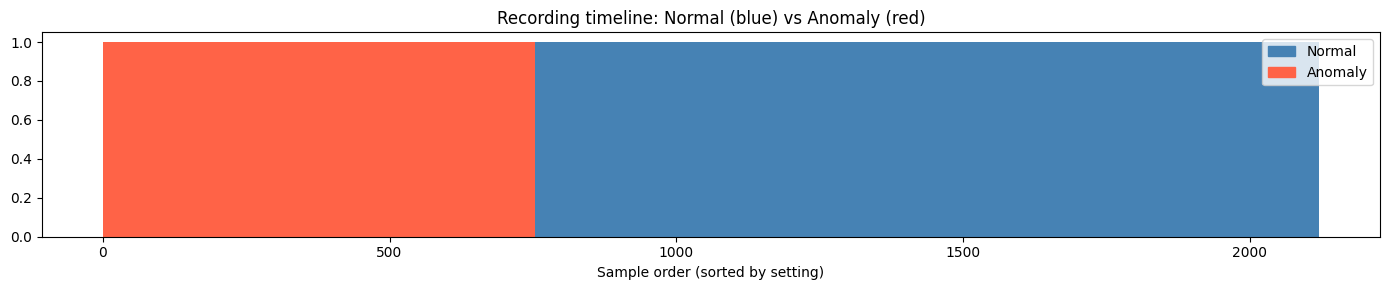


First anomaly appears at sorted position: 0
Setting value at that position: 0
Pure normal samples before first anomaly: 0


In [16]:
# Sort samples by setting (proxy for recording time)
sample_meta_sorted = sample_meta.sort_values('setting').reset_index(drop=True)

# Visualize the recording order
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 3))
colors = sample_meta_sorted['anomaly'].map({False: 'steelblue', True: 'tomato'})
ax.bar(range(len(sample_meta_sorted)), 1, color=colors, width=1)
ax.set_xlabel("Sample order (sorted by setting)")
ax.set_ylabel("")
ax.set_title("Recording timeline: Normal (blue) vs Anomaly (red)")

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='steelblue', label='Normal'),
                   Patch(color='tomato', label='Anomaly')])
plt.tight_layout()
plt.savefig("recording_timeline.png", dpi=120)
plt.show()

# Find the boundary: where anomalies start appearing
# Training set = early block of ONLY normal samples
normal_mask = sample_meta_sorted['anomaly'] == False
anomaly_first_idx = sample_meta_sorted[sample_meta_sorted['anomaly'] == True].index[0]
print(f"\nFirst anomaly appears at sorted position: {anomaly_first_idx}")
print(f"Setting value at that position: {sample_meta_sorted.iloc[anomaly_first_idx]['setting']}")

# Count normal samples before first anomaly
pure_normal_block = sample_meta_sorted[sample_meta_sorted.index < anomaly_first_idx]
print(f"Pure normal samples before first anomaly: {len(pure_normal_block)}")
# This should be close to 948

<Axes: xlabel='time'>

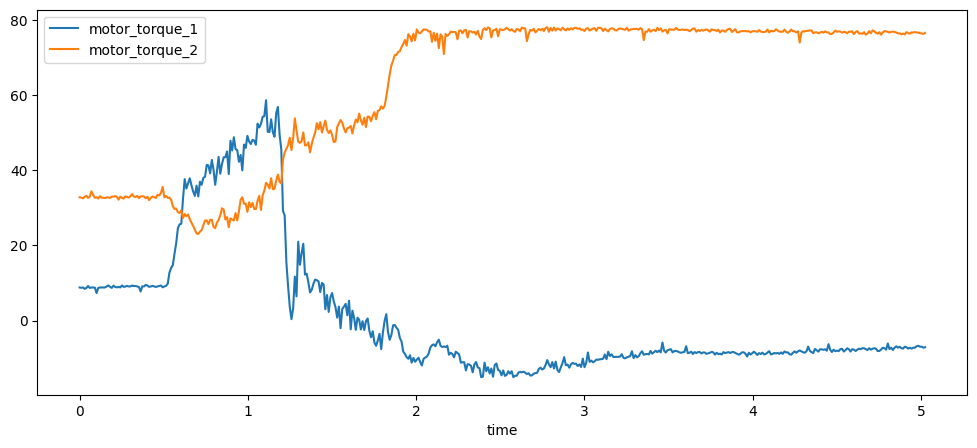

In [17]:
# Plotting first 500 samples of data
df.iloc[:500].plot(x='time', y=['motor_torque_1', 'motor_torque_2'], figsize=(12, 5))

First 20 samples by ID:
    sample  anomaly  category  setting
0        0     True         0        0
1        1     True         0        0
2        2     True         0        0
3        3     True         0        0
4        4     True         0        0
5        5     True         0        0
6        6     True         0        0
7        7     True         0        0
8        8     True         0        0
9        9     True         0        0
10      10     True         0        1
11      11     True         0        1
12      12     True         0        1
13      13     True         0        1
14      14     True         0        1
15      15     True         0        2
16      16     True         0        2
17      17     True         0        2
18      18     True         0        2
19      19     True         0        2

Last 20 samples by ID:
      sample  anomaly  category  setting
2102    2102    False        12       75
2103    2103    False        12       76
2104    21

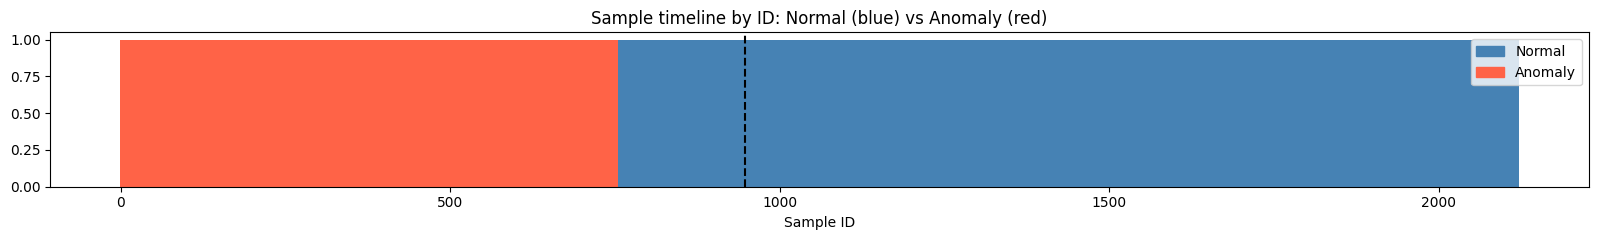

In [18]:
# Sort by sample ID and look at the pattern of normal vs anomaly
sample_meta_by_id = sample_meta.sort_values('sample').reset_index(drop=True)

# Find where normal vs anomaly samples sit in sample ID space
print("First 20 samples by ID:")
print(sample_meta_by_id[['sample', 'anomaly', 'category', 'setting']].head(20))

print("\nLast 20 samples by ID:")
print(sample_meta_by_id[['sample', 'anomaly', 'category', 'setting']].tail(20))

# Where do normal samples sit?
normal_ids = sample_meta_by_id[sample_meta_by_id['anomaly'] == False]['sample']
anomaly_ids = sample_meta_by_id[sample_meta_by_id['anomaly'] == True]['sample']

print(f"\nNormal sample ID range:  {normal_ids.min()} to {normal_ids.max()}")
print(f"Anomaly sample ID range: {anomaly_ids.min()} to {anomaly_ids.max()}")

# Check if any normal samples exist before sample ID 948
early_normal = sample_meta_by_id[
    (sample_meta_by_id['sample'] < 948) & (sample_meta_by_id['anomaly'] == False)
]
early_anomaly = sample_meta_by_id[
    (sample_meta_by_id['sample'] < 948) & (sample_meta_by_id['anomaly'] == True)
]
print(f"\nSample IDs 0–947  → Normal: {len(early_normal)}, Anomaly: {len(early_anomaly)}")

late_normal = sample_meta_by_id[
    (sample_meta_by_id['sample'] >= 948) & (sample_meta_by_id['anomaly'] == False)
]
late_anomaly = sample_meta_by_id[
    (sample_meta_by_id['sample'] >= 948) & (sample_meta_by_id['anomaly'] == True)
]
print(f"Sample IDs 948–2121 → Normal: {len(late_normal)}, Anomaly: {len(late_anomaly)}")

# Visualize the full timeline by sample ID
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(16, 2.5))
colors = sample_meta_by_id['anomaly'].map({False: 'steelblue', True: 'tomato'})
ax.bar(sample_meta_by_id['sample'], 1, color=colors, width=1)
ax.axvline(x=948, color='black', linestyle='--', linewidth=1.5, label='ID=948 boundary')
ax.set_xlabel("Sample ID")
ax.set_title("Sample timeline by ID: Normal (blue) vs Anomaly (red)")
ax.legend(handles=[
    Patch(color='steelblue', label='Normal'),
    Patch(color='tomato', label='Anomaly'),
])
plt.tight_layout()
plt.savefig("sample_id_timeline.png", dpi=120)
plt.show()

In [19]:
# Check if 'setting' 72-76 are ALL normal and map to train
print("Setting 72-76 sample counts and anomaly status:")
print(sample_meta[sample_meta['setting'] >= 72].groupby(['setting', 'anomaly']).size())

# Check action column per sample
sample_meta['action_first'] = df.groupby('sample')['action'].first().values
print("\nAction value counts for normal samples:")
print(sample_meta[sample_meta['anomaly']==False]['action_first'].value_counts())

Setting 72-76 sample counts and anomaly status:
setting  anomaly
72       False      948
73       False      319
74       False       37
75       False       44
76       False       19
dtype: int64

Action value counts for normal samples:
action_first
0    1367
Name: count, dtype: int64


In [20]:
print(sample_meta['n_timesteps'].describe())
print(sample_meta['n_timesteps'].value_counts().sort_index())

# Separately for normal vs anomaly
print(sample_meta.groupby('anomaly')['n_timesteps'].describe())
print(sample_meta.groupby('anomaly')['n_timesteps'].value_counts().sort_index())

count    2122.000000
mean     1094.104618
std        23.228248
min       986.000000
25%      1082.000000
50%      1096.000000
75%      1110.000000
max      1164.000000
Name: n_timesteps, dtype: float64
n_timesteps
986       2
987       1
1000      2
1014      2
1027      1
1028      1
1041     13
1054     24
1055     71
1059      1
1062      3
1068    132
1069    190
1071      1
1073      1
1076      1
1078      1
1079      2
1080      1
1082    371
1083    101
1084      1
1087      1
1088      1
1090      1
1091      3
1093      1
1094      1
1095     22
1096    467
1097      1
1099      3
1100      1
1102      1
1103      2
1104      1
1105      1
1107      1
1108      2
1109    124
1110    199
1112      1
1119      1
1120      1
1121      2
1122      1
1123    142
1124     72
1127      1
1132      1
1137     97
1144      1
1147      1
1150     11
1151     31
1164      3
Name: count, dtype: int64
          count         mean        std     min     25%     50%     75%  \
anomaly      

In [21]:
# 986 is the min but it's only 2 samples — don't penalize everyone for outliers
# 1041 captures 25th percentile of normals cleanly
# Safe choice: use the 5th percentile of the full distribution

import numpy as np
p5 = int(np.percentile(sample_meta['n_timesteps'], 5))  # → 1055

MAX_LEN = 1055  # keeps 95% of samples intact, only 3 samples (986,987,1000) are shorter

In [22]:
def load_and_truncate(sample_id, max_len=MAX_LEN):
    seq = load_sequence(sample_id)  # (T, features)
    if len(seq) < max_len:
        # Option A: pad with zeros (or mean)
        pad = np.zeros((max_len - len(seq), seq.shape[1]))
        seq = np.vstack([pad, seq])  # pre-pad to preserve recency
    else:
        seq = seq[-max_len:]  # take last N steps
    return seq

In [23]:
# Are the very short sequences (986, 987, 1000) normal or anomalous?
print(sample_meta[sample_meta['n_timesteps'] < 1041][['sample', 'anomaly', 'n_timesteps']])

      sample  anomaly  n_timesteps
442      442     True          986
443      443     True         1000
444      444     True          987
447      447     True         1000
449      449     True         1014
450      450     True         1027
451      451     True         1014
452      452     True          986
1479    1479    False         1028
